# Pre 4C - Generative Transformer (Further Reading)

In this tutorial, we will implement the transformer architecture based on the seminal paper *"Attention is All You Need"* in a step-by-step manner. Along the way, we’ll compare our implementation with the original paper and simplify the concepts to make them more accessible while preserving the core ideas.

## References
- This tutorial is based off Andrej Karpathy’s YouTube video, ["Let's build GPT: from scratch, in code, spelled out."](https://youtu.be/kCc8FmEb1nY?si=N9RXdNbe5HYUhknl)
- It also incorporates details and insights directly from the original transformer paper, [*"Attention is All You Need"*](https://arxiv.org/abs/1706.03762).

## Getting Started
We will begin by importing the necessary PyTorch packages and detecting available GPU devices to ensure our model runs efficiently. This foundational step sets up the environment for building and training the transformer model.

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import matplotlib.pyplot as plt

## Data Loading and Tokenization

The transformer architecture was introduced in the seminal paper *"Attention is All You Need"* for language translation tasks. The authors trained their model on the bilingual datasets, which contains approximately 4.5 million sentence pairs. This bilingual dataset was well-suited for translation, as it allowed the model to learn mappings between two languages.

For this tutorial, we will simplify the objective to generating text in the style of William Shakespeare. Instead of tackling the complexity of translation, we will focus on text generation, which lets us explore the core mechanics of the transformer architecture in a more straightforward way. This shift highlights the model's ability to generate coherent sequences while keeping the implementation accessible.

To do this, we will use the Tiny Shakespeare dataset, a compact collection of William Shakespeare’s works. This dataset is widely used in educational settings because it is small enough to manage easily, yet rich enough to demonstrate how transformers capture linguistic patterns. 

Let’s start by loading the Tiny Shakespeare dataset and examining the characters it contains. This will be our first step toward tokenizing the text and preparing it for the transformer model.

In [2]:
with open('input.txt') as f:
    text = f.read()

print(f"The dataset has {len(text)} characters in total.")

vocab = ''.join(sorted(list(set(text))))
vocab_size = len(vocab)

print(f"{vocab_size} different characters are found in the file:")
print(vocab)

The dataset has 1115394 characters in total.
65 different characters are found in the file:

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## Tokenization

In the original *"Attention is All You Need"* paper, the authors employed byte-pair encoding (BPE) for tokenization, resulting in a vocabulary size exceeding 32,000 subword units. This approach is effective for large, diverse datasets, as it balances granularity and computational efficiency. However, for our task of generating Shakespeare-like text with our small dataset, such a large vocabulary and the associated computational demands are excessive.

Instead, we will stick with a simpler character-level tokenization approach. By representing each unique character in the dataset as an integer, we keep the vocabulary small and manageable—specifically, 65 unique characters for Tiny Shakespeare (including letters, punctuation, and special characters).

Tokenization is a critical step in language model development, and various advanced techniques exist beyond BPE. For further reading, consider exploring Google’s *SentencePiece*, which integrates subword tokenization with language-agnostic preprocessing, or OpenAI’s *Tiktoken*, optimized for efficiency in large-scale models like GPT. These methods highlight the evolving landscape of tokenization strategies.

Here, we will convert the characters of the Tiny Shakespeare dataset into integers ranging from 0 to 64, corresponding to the dataset’s unique character set. Following this, we will split the tokenized data into training and validation sets to prepare for model training.

In [3]:
## Character-level Tokenizer Implementation
char2int = {c:i for i, c in enumerate(vocab)}
int2char = {i:c for i, c in enumerate(vocab)}

def string2int(s): 
    return [char2int[c] for c in s]
    
def int2string(I):
    return ''.join([int2char[i] for i in I])

print(string2int("Hello"))
print(int2string([20, 43, 50, 50, 53]))

[20, 43, 50, 50, 53]
Hello


In [4]:
## Converting the dataset to integers and splitting
dataset = torch.tensor(string2int(text), dtype=torch.long)

n = int(0.9*len(dataset))
train_dataset = dataset[:n]
val_dataset = dataset[n:]

## Creating Batches

This script provides a generator that iterates through the tokenized dataset and returns batches of sequences. Each batch is structured as a tensor of shape `B x T`, where:
- `B` represents the batch size, or the number of independent sequences processed simultaneously.
- `T` denotes the block size, or the number of characters in each sequence.

Additionally, the script generates a target tensor alongside the input tensor. The target tensor is simply the input tensor shifted by one character position. For example, if the input sequence is `"to be or"`, the target sequence would be `"o be or "`. This shifted pairing facilitates the calculation of the loss.

In [5]:
# data loading
def get_batch(data):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [6]:
batch_size = 4
block_size = 8 

batch = get_batch(train_dataset)


x, y = batch
print(f"input tensor:\n {x}")
print("\n")
print(f"target tensor:\n {y}")

input tensor:
 tensor([[50, 63,  1, 41, 53, 51, 54, 50],
        [47, 51, 43,  1, 47, 52,  1, 63],
        [ 1, 39,  1, 51, 39, 52, 12,  0],
        [43,  1, 44, 53, 56,  1, 58, 46]], device='cuda:0')


target tensor:
 tensor([[63,  1, 41, 53, 51, 54, 50, 39],
        [51, 43,  1, 47, 52,  1, 63, 53],
        [39,  1, 51, 39, 52, 12,  0, 13],
        [ 1, 44, 53, 56,  1, 58, 46, 47]], device='cuda:0')


---

## Network Implementation

The transformer architecture, as introduced in *"Attention is All You Need"*, is both flexible and highly scalable. It consists of a series of blocks arranged in parallel and stacked sequentially. Implementing the entire model within a single class would be inefficient and limit flexibility. To address this, we will break down the implementation into modular pieces, constructing each part individually before integrating them into the final model for training and evaluation.

Let us begin by examining the main figure from the original paper:

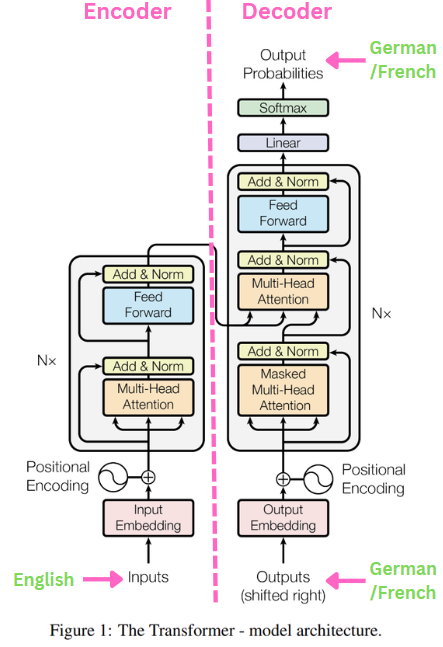

*Figure 1. The transformer architecture (Vaswani et al., 2017)*

This diagram illustrates the full transformer architecture, which is divided into two primary components:
- **Encoder (right column)**: Processes the input sequence (e.g., English sentences in the original paper) to create a contextual representation.
- **Decoder (left column)**: Generates the output sequence (e.g., French or German translations) by attending to the encoder’s output and its own previous predictions.

In the original paper, the transformer was designed for translation, with English inputs and French or German outputs. However, since our goal is to generate Shakespeare-like text rather than perform translation, we can simplify the architecture by eliminating the encoder entirely. For text generation, the decoder alone is sufficient, as it can autoregressively predict the next character based on the sequence it has generated so far.

The simplified architecture we will implement is shown below:

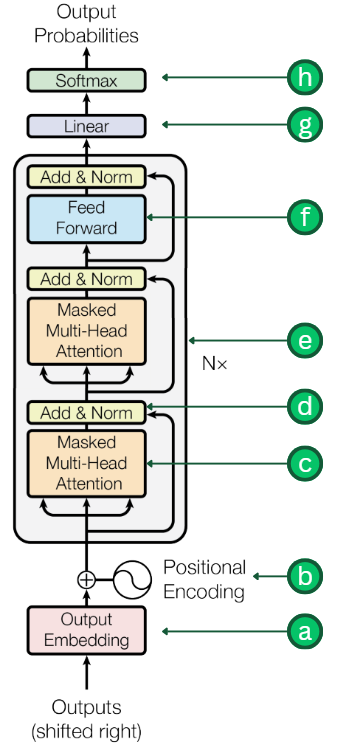

*Figure 2. The simplified transformer architecture for text generation*

This simplified design retains the decoder’s core multi-head-attention and feed-forward layers, while adapting it for our generative task using the Tiny Shakespeare dataset. In the following sections, we will build this decoder step-by-step, starting with its fundamental building blocks.

### Embedding Space

In the transformer architecture, the first step in processing input tokens is to map each token to a vector of size `n_embd x 1` using a lookup table populated with trainable parameters, as depicted in Figure 2(a). For our character-level tokenization with the Tiny Shakespeare dataset, each character is assigned a unique embedding vector. This lookup table can be efficiently implemented in PyTorch using the `nn.Embedding` module. Given the straightforward nature of this layer, we will defer its implementation until the final step, when we assemble all the transformer’s building blocks into a cohesive model.

While the embedding layer maps each token (in our case, a character) into a higher-dimensional space, it does not inherently capture the positional information of tokens within the sequence. Unlike recurrent neural networks, transformers lack a built-in sense of order or sequence awareness, making positional encoding essential.

To address this, the original *"Attention is All You Need"* paper introduces sinusoidal positional embeddings, which are added to the token embeddings to encode the position of each token in the sequence, as shown in Figure 2(b). These embeddings use sine and cosine functions to create vectors that vary smoothly with position, enabling the model to distinguish token order. The paper proposes the following formulas for positional encoding:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / n_{\text{embd}}}}\right)
$$

$$
PE_{(pos, 2i + 1)} = \cos\left(\frac{pos}{10000^{2i / n_{\text{embd}}}}\right)
$$

Here, `pos` is the position of the token in the sequence, `i` is the dimension index within the embedding vector, and `n_embd` is the embedding dimension. The use of sinusoidal functions ensures that positional differences are learnable and generalizable across sequence lengths.

In our implementation, we will create a class to compute these positional embeddings using the same formulas. To ensure numerical stability—particularly for large values of `n_embd` or `pos`—we will first compute the logarithm of the denominator’s exponent and then apply the exponential function. This can be expressed as:

$$
\text{argument} = e^{\ln(10000) \cdot \frac{2i}{n_{\text{embd}}}} = 10000^{\frac{2i}{n_{\text{embd}}}}
$$

While it is possible to compute the arguments directly, this logarithmic approach minimizes potential floating-point precision issues. The resulting positional embeddings will be added to the token embeddings, preparing the input for the transformer’s attention mechanism.

In [7]:
class SinusoidalPositionalEncoding(nn.Module):
    """ Sinusoidal positional encoding from 'Attention Is All You Need' """
    def __init__(self, block_size, n_embd):
        super().__init__()

        position = torch.arange(block_size).unsqueeze(1)  # Shape: (T, 1)
        div_term = torch.exp(torch.log(torch.tensor(10000.0)) * torch.arange(0, n_embd, 2) / n_embd)

        # Apply sine to even indices, cosine to odd indices
        pe = torch.zeros(block_size, n_embd)
        pe[:, 0::2] = torch.sin(position * div_term)  # Apply sine to even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # Apply cosine to odd indices

        # Register as buffer (non-trainable parameter)
        self.register_buffer('pe', pe)

    def forward(self, idxs):
        """Returns positional encodings matching input size"""
        return self.pe[idxs, :].unsqueeze(0).to(idxs.device)  # Shape: (1, T, C)

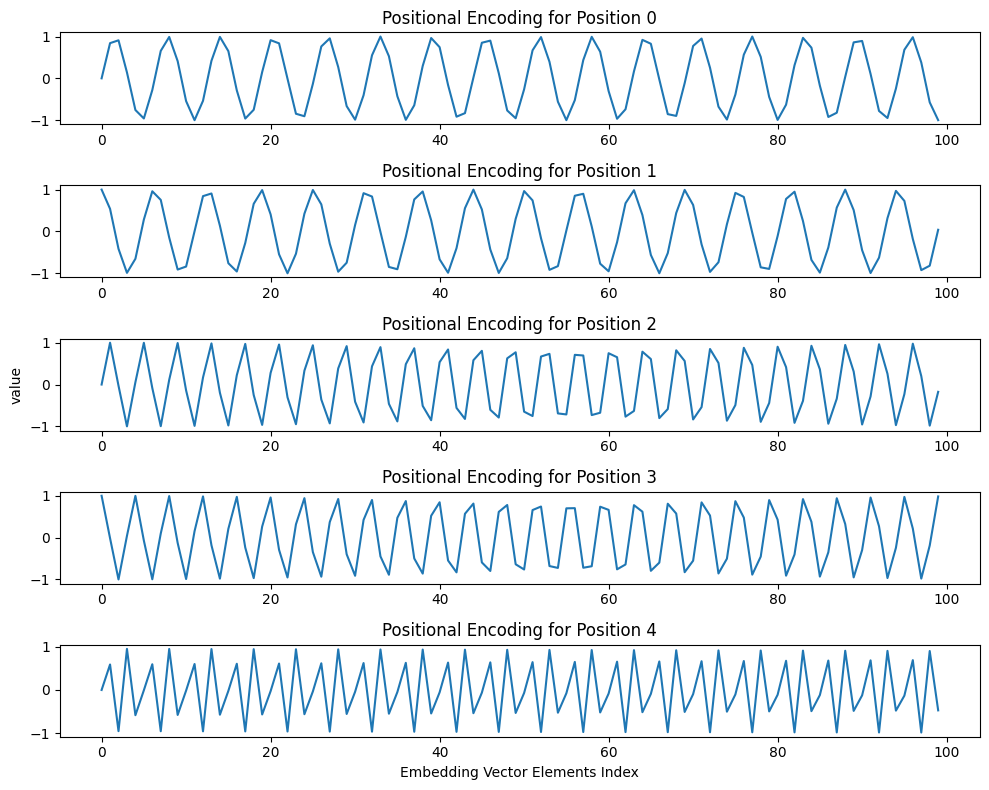

In [8]:
## Testing the sinusoidal positional embedding
## Assume each sequence is made of 100 characters and n_embd = 40

PositionalEncoding = SinusoidalPositionalEncoding(block_size = 100, n_embd = 40)

# Now, we have an object that will take a list of positions we are interested in 
# and returns their positional embeddig as a (1 x T x C) tensor
# To plot it, we have to get read of the first dimension.
pe = PositionalEncoding(torch.arange(100)).squeeze(0)

fig, axs = plt.subplots(5, 1, figsize=(10, 8))  # 5 rows, 1 column
for i in range(5):
    axs[i].plot(pe[:,i])
    axs[i].set_title(f"Positional Encoding for Position {i}")

axs[4].set_xlabel("Embedding Vector Elements Index")
axs[2].set_ylabel("value")

plt.tight_layout()

### Scaled Dot-Product Attention

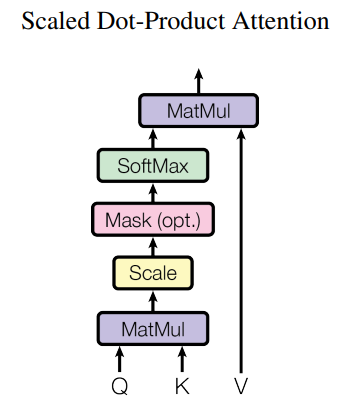

*Figure 3. Architecture of an attention head*

The core mechanism of the transformer architecture is the scaled dot-product attention and defined as:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{n_{\text{embd}}}}\right)V
$$

This mechanism, often referred to as an "attention head," enables the model to weigh the importance of different tokens in the input sequence. Here, `Q` (Query), `K` (Key), and `V` (Value) are vectors derived from the input embeddings. The dot product `QK^T` measures the similarity between queries and keys, which is then scaled by \(\sqrt{n_{\text{embd}}}\)—the square root of the embedding dimension—to prevent large values that could destabilize gradients. The softmax operation converts these scores into probabilities, which are used to weight the values (`V`) and produce the final output.

To compute `Q` and `K`, we will use two fully connected layers. These layers take inputs of size `n_embd` (the embedding dimension) and produce outputs of size `head_size`, a new hyperparameter defining the dimensionality of each attention head. Since a normalization layer typically follows, adding biases to these layers would be redundant, so we will disable them to simplify the computation. The scaling factor \(\sqrt{n_{\text{embd}}}\) enhances numerical stability by mitigating the risk of exploding dot products, especially when `n_embd` is large.

#### Causal Masking
For our text generation task, we must ensure that the model only attends to previous characters in the sequence, not future ones, to maintain autoregressive behavior. To achieve this, we will apply a causal mask. This mask can be created using `torch.tril()`, which generates a lower triangular matrix, zeroing out all elements above the diagonal. This effectively prevents attention from flowing from earlier characters to later ones in the sequence.

Since this mask is static and not trainable, we will compute it once during model initialization and store it for reuse. A useful PyTorch trick is to use `self.register_buffer()` within an `nn.Module` subclass. This registers the mask as a buffer, ensuring it is saved with the model but excluded from gradient computations, avoiding unnecessary complexity in autograd.

Applying the mask directly after the softmax layer would complicate the process, as it would require adjusting the softmax’s receptive field for each position, undermining the transformer’s parallelism. Instead, we will apply the mask before the softmax by setting the masked elements in `QK^T / \sqrt{n_{\text{embd}}}` to negative infinity (`-inf`). When passed through the softmax, these `-inf` values will automatically become zero probabilities, effectively eliminating attention to future characters. The resulting attention matrix will have its upper triangle filled with zeros, enforcing the causal structure.

Finally, we will define another fully connected layer to implement the values (`V`), corresponding to the rightmost arrow in Figure 3. This layer is multiplied by the output of the softmax operation to produce the attention head’s final output. In this mechanism:
- **Queries and Keys**: Determine where to look by computing relevance scores between tokens.
- **Values**: Carry the actual data or features to be passed forward, based on the attention weights.

In [9]:
## An example of torch.tril()
torch.tril(torch.ones(5, 5))

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

In [10]:
## Scaled dot-product attention
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        # making a mask to be used in the model and registering it into the class buffer.
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        v = self.value(x) # (B,T,C)
        
        # compute attention matrix
        attention = q @ k.transpose(-2,-1)  # (B, T, C) @ (B, C, T) -> (B, T, T)
        # The dinominator of the formula RHS
        # Instead of calculating the square root and then dividing, we use power of -.5
        attention = attention * C**-0.5
        # change the values of the elements above the diagonal elements to -inf
        attention = attention.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        attention = F.softmax(attention, dim=-1) # (B, T, T)
        attention = self.dropout(attention)
        
        # generating the output
        out = attention @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

### Multihead Attention

A single attention head, as described in the previous section, has limited capacity to capture the full complexity of language. Each head can focus on a specific aspect of linguistic structure—for example, identifying adjectives related to a noun or modifiers associated with a verb. To build a more powerful transformer capable of modeling diverse language patterns, we need multiple attention heads, each learning to attend to different facets of the input sequence. This mechanism, known as multihead attention, is a key component of the transformer architecture, as illustrated in Figure 2(c) of our simplified design.

Multihead attention operates by running multiple attention heads in parallel, with each head computing its own scaled dot-product attention independently. The outputs of these heads are then concatenated to form a richer representation of the input. This parallelism allows the model to simultaneously explore various relationships within the text, enhancing its ability to generate coherent and contextually appropriate sequences.

The architecture of multihead attention is depicted below:

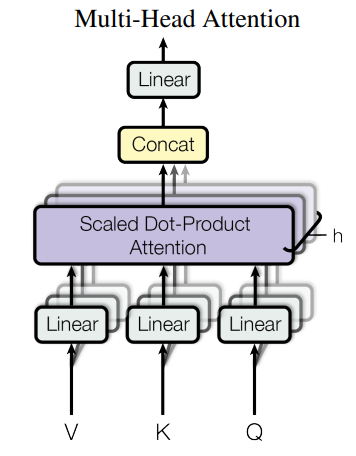

*Figure 4. Multihead Attention*

To implement this, we will define a subclass of `nn.Module` that encapsulates `n_head` attention heads. Within this class, we will use `nn.ModuleList` to manage a list of attention head modules. The `nn.ModuleList` ensures that all submodules remain within the scope of our multihead attention class, registering their parameters for training. In the forward pass, we will iterate through this list, compute the output of each attention head, and concatenate the results along the appropriate dimension. This concatenated output will then be passed to subsequent layers of the transformer.

In [11]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out

### FeedForward

At the end of each transformer layer, following the multihead attention mechanism, there is a feedforward block (figure 2(f)). This block consists of a simple two-layer fully connected neural network with a ReLU activation function between the layers. According to the *"Attention is All You Need"* paper, the feedforward network serves as a position-wise transformation, processing each token’s representation independently to enhance the model’s capacity to capture complex patterns.

The paper recommends that the hidden layer of this feedforward network be four times larger than the input dimension, `n_embd`. Thus, if the input and output dimensions are `n_embd`, the hidden layer will have a size of `ffw_hidden`. This expansion allows the network to project the input into a higher-dimensional space, where non-linear transformations via ReLU can model intricate relationships, before projecting it back to the original dimension.

In [12]:
class FeedFoward(nn.Module):
    def __init__(self, n_embd, ffw_hidden):
        super().__init__()
    
        self.fc1 = nn.Linear(n_embd, ffw_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(ffw_hidden , n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.fc2(self.relu(self.fc1(x))))

### Transformer Layer

As shown in Figure 2(e), the transformer architecture consists of a series of repeated layers that form its core structure. Each layer, depicted in Figure 2(e), comprises the following components:
1. **Multihead Attention**: Captures diverse linguistic relationships across the sequence.
2. **Residual Pathways**: Three residual connections that add the input of a block to its output, aiding gradient flow and training stability.
3. **Feedforward Block**: A position-wise fully connected network that refines token representations.

In this section, we will assemble the building blocks we previously developed—multihead attention and the feedforward network—into a single transformer layer. This modular design allows us to repeat the layer multiple times later, adjusting the network’s depth and complexity as needed for generating Shakespeare-like text with the Tiny Shakespeare dataset.

#### Layer Normalization
Following the multihead attention and feedforward blocks, each transformer layer includes a normalization step. Unlike batch normalization, which normalizes across the batch dimension, the transformer uses layer normalization. Layer normalization operates independently of batch size, normalizing across the features (i.e., the `n_embd` dimension) for each token in the sequence.

In practice, we will place a layer normalization step after the multihead attention block and another after the feedforward block, each paired with a residual connection. This structure enhances training efficiency and model performance by mitigating issues like vanishing gradients.

By combining these components, we create a transformer layer ready to be stacked to form the final architecture.

In [13]:
class Layer(nn.Module):
    """ Transformer layer"""

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa1 = MultiHeadAttention(n_head, head_size)
        self.sa2 = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd, ffw_hidden)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ln3 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + (self.sa1(self.ln1(x)))
        x = x + (self.sa2(self.ln2(x)))
        x = x + (self.ffwd(self.ln3(x)))
        return x

### Transformer Implementation

Now, it is time to assemble the complete transformer model. Transformers are highly scalable, allowing us to adjust their complexity by increasing the number of layers (`n_layer`) or the number of heads in the multihead attention mechanism (`n_heads`). This flexibility enables us to control the model’s parameter count and capacity to suit our needs for generating Shakespeare-like text with the Tiny Shakespeare dataset.

#### Model Construction
We will begin by tokenizing the input using two embedding tables:
1. **Token Embedding**: Maps each character to a vector of size `n_embd` using a lookup table (`nn.Embedding`).
2. **Positional Embedding**: Adds positional information to each token’s embedding using sinusoidal functions, as described earlier.

These two embeddings are summed element-wise to produce a combined representation that encodes both the character identity and its position in the sequence.

Next, we will stack multiple transformer layers using `nn.Sequential`. This PyTorch class takes a list of `n_layer` transformer layers and automatically feeds the output of one layer into the next, streamlining the forward pass through the stack. Each layer includes multihead attention, residual connections, layer normalization, and a feedforward block, as previously defined.

#### Output Processing
The output of the transformer layer stack is then passed through an additional `nn.LayerNorm` layer. While not explicitly mentioned in the *"Attention is All You Need"* paper, this final normalization step has been widely adopted in modern transformer implementations (e.g., GPT) for its significant improvement in training stability and convergence.

Following normalization, we will add a fully connected layer to project the `n_embd`-dimensional embeddings back into the vocabulary space (size 65 for Tiny Shakespeare). This layer outputs logits for each possible character. To convert these logits into probabilities over the vocabulary, we will apply a softmax operation to identify the most likely next character in the sequence.

#### Text Generation
To enable text generation, we will implement a `generate` method within the transformer class. This method operates as follows:
- Start with an initial context (e.g., a short string of characters).
- Feed the context into the model to obtain a probability distribution over the next character, derived from the softmax output.
- Use `torch.multinomial` to sample a character from this distribution, introducing randomness to mimic creative generation.
- Append the sampled character to the context and repeat the process, feeding the updated sequence back into the model until the desired length is reached.

In [14]:
class Transformer(nn.Module):
    """Transformer Architecture"""
    
    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = SinusoidalPositionalEncoding(block_size, n_embd)
        self.layers = nn.Sequential(*[Layer(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.layers(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)
        
        return logits
        
    def generate(self, starting_context, generated_token, online_print = True, select_top=4):
        if online_print:
            print(int2string(starting_context[0].tolist()), end = "")
        # idx is (B, T) array of indices in the current context
        for _ in range(generated_token):
            # crop the starting context to the size of transformer input
            cropped_context = starting_context[:, -block_size:]
            # get the predictions
            logits = self(cropped_context)
            # softmax layer shown in figure 2(h)
            probablities = F.softmax(logits[:,-1,:], dim=-1) # (B, C)
            # Get the top-k probabilities and their indices 
            # to prevent appearance of irrelevant characters
            topk_probs, topk_indices = torch.topk(probablities, select_top)
            # Create a masked tensor with only top-k elements (others set to 0)
            masked_probs = torch.zeros_like(probablities)
            masked_probs[0, topk_indices] = topk_probs  # Use original top-k values, unnormalized
            # Sampling from the high probablity characters
            next_char = torch.multinomial(masked_probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            starting_context = torch.cat((starting_context, next_char), dim=1) # (B, T+1)
            # This feature does not work properly in Jupyter notebook.
            if online_print:
                print(int2char[next_char.item()], end = "")
                
        return starting_context

---

### Training Time

Now, it is time to train the transformer model we have constructed. Training involves defining hyperparameters, instantiating the model, and iterating through the dataset to optimize its parameters. To monitor progress, we will compute the training and validation loss every 100 iterations.

To keep the initial training manageable, we will start with a smaller model configuration—fewer layers and heads—to ensure faster iteration and debugging. Once we verify that the training process works effectively, we can scale up to a larger model with increased complexity for better performance.

In [15]:
def train():
    val_loss = []
    train_loss = []
    
    model = Transformer()
    m = model.to(device)
    # print the number of parameters in the model
    print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters \n')
    
    # create a PyTorch optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    
    for iter in range(max_iters):
    
        # every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0 or iter == max_iters - 1:
            model.eval()
            
            print(f"Iteration {iter}:", end=" ", flush=True)
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(train_dataset)
                logits = model(X)
                B, T, C = logits.shape
                logits = logits.view(B*T, C)
                Y = Y.view(logits.shape[0])
                loss = F.cross_entropy(logits, Y)
                losses[k] = loss.item()
            train_loss.append(losses.mean().item())
            print(f"training loss={train_loss[-1]:.4f}", end="")
            
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(val_dataset)
                logits = model(X)
                B, T, C = logits.shape
                logits = logits.view(B*T, C)
                Y = Y.view(logits.shape[0])
                loss = F.cross_entropy(logits, Y)
                losses[k] = loss.item()
            val_loss.append(losses.mean().item())
            print(f", validation loss={val_loss[-1]:.4f}")
             
            model.train()
        # sample a batch of data
        X, Y = get_batch(train_dataset)
    
        # evaluate the loss
        logits = model(X)
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        Y = Y.view(logits.shape[0])
        loss = F.cross_entropy(logits, Y)
        
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    
    # Assuming loss is recorded every 100 iterations
    iterations = [i * eval_interval for i in range(len(train_loss))]
    
    # Create the plot
    plt.figure(figsize=(8, 5))  # Set figure size for readability
    plt.plot(iterations, train_loss, label='Training Loss', color='blue', linewidth=2)
    plt.plot(iterations, val_loss, label='Validation Loss', color='orange', linewidth=2)
    
    # Add titles and labels
    plt.title('Training and Validation Loss Curves', fontsize=14, pad=10)
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Add a legend
    plt.legend(fontsize=10)
    
    # Add a grid for better readability
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.show()
    
    # generate from the model
    context = torch.tensor(string2int('To be or, not to be, '), dtype=torch.long, device=device).unsqueeze(0)
    print("Output Sample:")
    m.generate(context, generated_token = 2000, online_print = True)

0.273985 M parameters 

Iteration 0: training loss=4.4127, validation loss=4.4045
Iteration 250: training loss=2.4337, validation loss=2.4617
Iteration 500: training loss=2.3070, validation loss=2.3064
Iteration 750: training loss=2.1827, validation loss=2.2038
Iteration 1000: training loss=2.1164, validation loss=2.1525
Iteration 1250: training loss=2.0423, validation loss=2.1036
Iteration 1500: training loss=1.9818, validation loss=2.0551
Iteration 1750: training loss=1.9389, validation loss=2.0125
Iteration 2000: training loss=1.8935, validation loss=2.0038
Iteration 2250: training loss=1.8741, validation loss=1.9728
Iteration 2500: training loss=1.8516, validation loss=1.9229
Iteration 2750: training loss=1.8129, validation loss=1.9407
Iteration 3000: training loss=1.8007, validation loss=1.9244
Iteration 3250: training loss=1.7860, validation loss=1.9030
Iteration 3500: training loss=1.7607, validation loss=1.9096
Iteration 3750: training loss=1.7664, validation loss=1.8898
Iterat

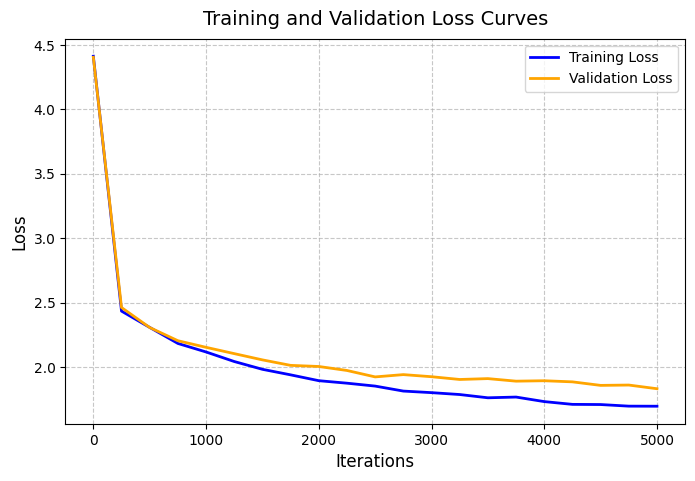

Output Sample:
To be or, not to be, I will as had
To he deed of as to donister, I'll brother a fear angenders foot of his haded,
Then this the sear in the wilere to be fears, I am to the doth thee, a give
Male of yield forthis hear the seent and of me,
And so to there the somes as alper this before
Than he will he death here sended of him true a to sentless
And that the to-swener, and
I with see as this the heer,
To seeed to the dear an thae sound and for the sheed a commence, thou brother
As that take true to thee dindown thee,
And with and thinguess, tile the feal, the she do sons, their bean and figner forsomed my fier herselved and thisher
To to my live haves and there the storright.
The confice to make and this the sunt the come to me
Where that singer a fords, wesenter,
That I baway to me be this befored
And swerands the have
To to-hour the by son how the canger the sence of of mortan
Wen his to seents and the dead, a so, and then ander
The beast thee father and blessers,
As and 

In [16]:
# hyperparameters
batch_size = 16 # the number of the sequences in a batch
block_size = 32 # the sequence length
max_iters = 5000 # training cycles limiter
eval_interval = 250 # evaluation every n cycle
learning_rate = 1e-3 # you know
eval_iters = 100 # when we are in evaluation mode, the evaluation is an average of losses on this many batches
n_embd = 64 # length of the embedding vector
n_head = 4 # number of transformer heads
n_layer = 4 # number of transformer layers
ffw_hidden = 4 * n_embd # FeedForward hidden layer size
dropout = 0.1
# ------------

train()

### Scaling the Model

As observed when comparing the results to those from Prelab 4B, the outputs of our current transformer model, despite its sophisticated architecture, do not yet match the performance of the LSTM model. Unlike LSTM models, which are constrained by sequential processing and struggle to scale efficiently, the transformer architecture is inherently parallelizable and highly adaptable. We can enhance its performance simply by adjusting hyperparameters, such as increasing the number of layers (`n_layer`), the number of attention heads (`n_heads`), or the embedding dimension (`n_embd`).

However, scaling up the model with a small dataset like Tiny Shakespeare introduces a potential challenge: excessive overfitting. To mitigate this, we can introduce a dropout layer after each transformer layer. Dropout randomly deactivates a fraction of neurons during training, encouraging the model to learn more robust and generalizable patterns.

#### Considerations for Execution
Note that scaling the model significantly increases its computational demands. The following configuration cannot be executed efficiently on Google Colab due to its resource limitations and will require a powerful GPU for training. Note that even with a scaled-up configuration reaching approximately 14 million parameters, our model remains significantly smaller than those deployed by leading organizations like OpenAI, DeepSeek, and xAI. These large-scale language models often have parameter counts in the billions, reflecting their training on vast datasets and their use of extensive computational resources. The table below compares the parameter sizes of some major LLMs to contextualize our model’s scale:

| Model            | Organization  | Parameter Count (Billions) |
|------------------|---------------|----------------------------|
| GPT-3            | OpenAI        | 175                        |
| Grok-3           | xAI           | 2700                       |
| DeepSeek-V3      | DeepSeek      | 671                        |
| LLaMA 13B        | Meta AI       | 13                         |
| Our Model        |               | 0.014                      |

*Table 1. Parameter counts of major LLMs compared to our scaled transformer model.*

14.236481 M parameters 

Iteration 0: training loss=4.3013, validation loss=4.3024
Iteration 500: training loss=2.4088, validation loss=2.4198
Iteration 1000: training loss=2.1149, validation loss=2.1600
Iteration 1500: training loss=1.9159, validation loss=2.0174
Iteration 2000: training loss=1.7645, validation loss=1.9297
Iteration 2500: training loss=1.6549, validation loss=1.8527
Iteration 3000: training loss=1.5708, validation loss=1.7990
Iteration 3500: training loss=1.5299, validation loss=1.7264
Iteration 4000: training loss=1.4736, validation loss=1.7067
Iteration 4500: training loss=1.4308, validation loss=1.6341
Iteration 5000: training loss=1.3887, validation loss=1.6476
Iteration 5500: training loss=1.3659, validation loss=1.6088
Iteration 6000: training loss=1.3403, validation loss=1.5842
Iteration 6500: training loss=1.3204, validation loss=1.5862
Iteration 7000: training loss=1.3059, validation loss=1.5461
Iteration 7500: training loss=1.2805, validation loss=1.5446
Ite

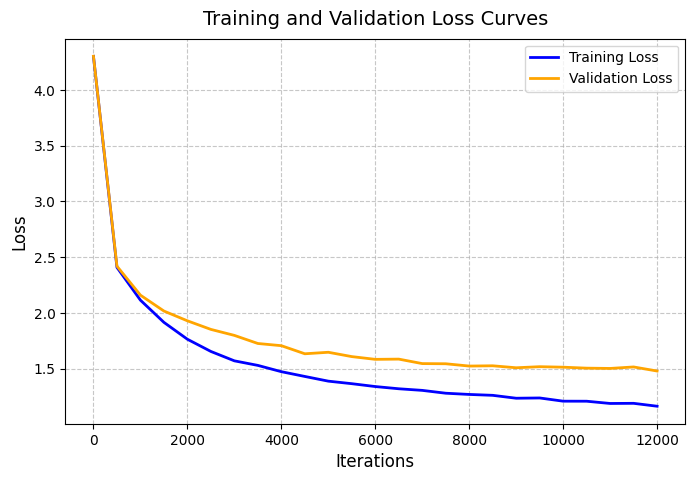

Output Sample:
To be or, not to be, and so long angel as
to the service of thing that with thy state,
Or she did sole thee weeds thou speak.

FLORIZEL:
Well, madam,
With thy son and the fear we that be seen
Show'd a for too late, as she with many second
Which we shall helm from him than should betwixt my
Have drams, and see his father that man stamp'd
The fourth or than the son.

LEONTES:
What shall be?

Provost:
I think they arm at that she distate more?
And then here, the manness of the sun offence.
We say they shell tell on, and they shall be.

LEONTES:
I was seal their for there womer and she wound.

LEONTES:
I'll be safe with many. Heaven, my lord.

PAULINUS:
Have you this?

POMPEY:
He's no mear the stir, sir, then my friar,
Hath been so much between the services of
Their sense that made to be rover'd to them
Thabit them at thousand to truth the world:
And I would have done, what I say, it shall sear all
Anontinued to me all, to their contempt of mine.
What should have been to bea

In [25]:
# hyperparameters
batch_size = 64 # the number of the sequences in a batch
block_size = 256 # the sequence length
max_iters = 12000 # training cycles limiter
eval_interval = 500 # evaluation every n cycle
learning_rate = 1.2e-4 # you know
eval_iters = 10 # when we are in evaluation mode, the evaluation is an average of losses on this many batches
n_embd = 384 # length of the embedding vector
n_head = 6 # number of transformer heads
n_layer = 6 # number of transformer layers
ffw_hidden = 4 * n_embd # FeedForward hidden layer size
dropout = 0.5
# ------------

train()